# Step_0_generate_stpsf

Generate JWST/NIRCam F115W STPSF models with supersampling factors 1 and 3, and save to `./psf_data`.


In [1]:
import os
from pathlib import Path
import warnings

import stpsf
from astropy.io import fits

warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('./psf_data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FILTER = 'F115W'
FOV_PIXELS = 101
NLAMBDA = 7

print('stpsf version:', stpsf.__version__)
print('output dir:', OUTPUT_DIR.resolve())


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


stpsf version: 2.1.0
output dir: /mnt/d/lensing/Herculens/Herculensedquasar/WFI2033/psf_data


In [2]:
def generate_psf(oversample: int):
    nircam = stpsf.NIRCam()
    nircam.filter = FILTER

    outfile = OUTPUT_DIR / f'F115W_PSF_stpsf_ss{oversample}.fits'

    _ = nircam.calc_psf(
        fov_pixels=FOV_PIXELS,
        oversample=oversample,
        nlambda=NLAMBDA,
        outfile=str(outfile),
        display=False,
    )

    with fits.open(outfile) as hdul:
        hdu_shapes = [(h.name, None if h.data is None else h.data.shape) for h in hdul]

    print(f'saved: {outfile}')
    print('  HDU shapes:', hdu_shapes)

    return outfile


In [3]:
out_ss1 = generate_psf(1)
out_ss3 = generate_psf(3)

print('done')
print('  ', out_ss1)
print('  ', out_ss3)


saved: psf_data/F115W_PSF_stpsf_ss1.fits
  HDU shapes: [('OVERSAMP', (101, 101)), ('DET_SAMP', (101, 101)), ('OVERDIST', (101, 101)), ('DET_DIST', (101, 101))]


saved: psf_data/F115W_PSF_stpsf_ss3.fits
  HDU shapes: [('OVERSAMP', (303, 303)), ('DET_SAMP', (101, 101)), ('OVERDIST', (303, 303)), ('DET_DIST', (101, 101))]
done
   psf_data/F115W_PSF_stpsf_ss1.fits
   psf_data/F115W_PSF_stpsf_ss3.fits


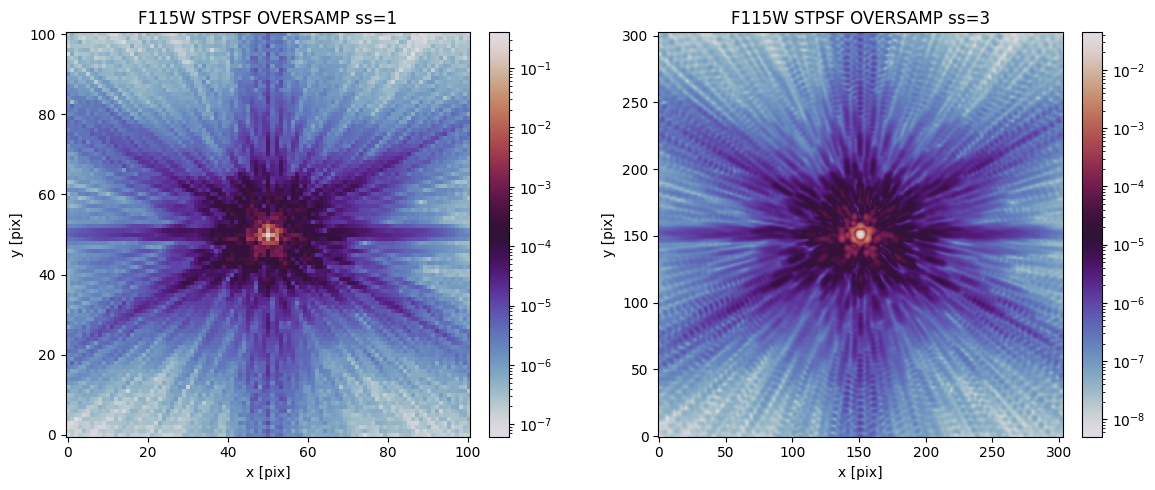

In [4]:
# PSF quick-look imshow
import matplotlib.pyplot as plt
from matplotlib import colors

psf_ss1 = fits.getdata(out_ss1, extname='OVERSAMP')
psf_ss3 = fits.getdata(out_ss3, extname='OVERSAMP')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(psf_ss1, origin='lower', cmap='twilight', norm=colors.LogNorm())
axes[0].set_title('F115W STPSF OVERSAMP ss=1')
axes[0].set_xlabel('x [pix]')
axes[0].set_ylabel('y [pix]')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(psf_ss3, origin='lower', cmap='twilight', norm=colors.LogNorm())
axes[1].set_title('F115W STPSF OVERSAMP ss=3')
axes[1].set_xlabel('x [pix]')
axes[1].set_ylabel('y [pix]')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
